In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.applications.vgg16 import VGG16 as PretrainedModel, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing import image

from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

In [2]:
!wget -nc https://archive.org/download/food-5-k/Food-5K.zip

File ‘Food-5K.zip’ already there; not retrieving.



In [3]:
!unzip -qq -o Food-5K

In [4]:
!ls

data	    Food-5K	 __MACOSX     training
evaluation  Food-5K.zip  sample_data  validation


In [5]:
!ls Food-5K/

evaluation  training  validation


In [6]:
!ls Food-5K/training

0_0.jpg     0_1387.jpg	0_422.jpg  0_809.jpg   1_1195.jpg  1_230.jpg  1_617.jpg
0_1000.jpg  0_1388.jpg	0_423.jpg  0_80.jpg    1_1196.jpg  1_231.jpg  1_618.jpg
0_1001.jpg  0_1389.jpg	0_424.jpg  0_810.jpg   1_1197.jpg  1_232.jpg  1_619.jpg
0_1002.jpg  0_138.jpg	0_425.jpg  0_811.jpg   1_1198.jpg  1_233.jpg  1_61.jpg
0_1003.jpg  0_1390.jpg	0_426.jpg  0_812.jpg   1_1199.jpg  1_234.jpg  1_620.jpg
0_1004.jpg  0_1391.jpg	0_427.jpg  0_813.jpg   1_119.jpg   1_235.jpg  1_621.jpg
0_1005.jpg  0_1392.jpg	0_428.jpg  0_814.jpg   1_11.jpg    1_236.jpg  1_622.jpg
0_1006.jpg  0_1393.jpg	0_429.jpg  0_815.jpg   1_1200.jpg  1_237.jpg  1_623.jpg
0_1007.jpg  0_1394.jpg	0_42.jpg   0_816.jpg   1_1201.jpg  1_238.jpg  1_624.jpg
0_1008.jpg  0_1395.jpg	0_430.jpg  0_817.jpg   1_1202.jpg  1_239.jpg  1_625.jpg
0_1009.jpg  0_1396.jpg	0_431.jpg  0_818.jpg   1_1203.jpg  1_23.jpg   1_626.jpg
0_100.jpg   0_1397.jpg	0_432.jpg  0_819.jpg   1_1204.jpg  1_240.jpg  1_627.jpg
0_1010.jpg  0_1398.jpg	0_433.jpg  0_81.jpg    1_1205.j

In [20]:
!mv Food-5K/* .

mv: cannot move 'Food-5K/evaluation' to './evaluation': Directory not empty
mv: cannot move 'Food-5K/training' to './training': Directory not empty
mv: cannot move 'Food-5K/validation' to './validation': Directory not empty


In [18]:
!ls

data	    Food-5K	 __MACOSX     training
evaluation  Food-5K.zip  sample_data  validation


In [19]:
plt.imshow(image.load_img('training/0_808.jpg'))

FileNotFoundError: [Errno 2] No such file or directory: 'training/0_808.jpg'

In [ ]:
plt.imshow(image.load_img('training/1_606.jpg'))

In [21]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


In [22]:
!mkdir data/train
!mkdir data/test

mkdir: cannot create directory ‘data/train’: File exists
mkdir: cannot create directory ‘data/test’: File exists


In [23]:
!mkdir data/train/food
!mkdir data/test/food
!mkdir data/train/nonfood
!mkdir data/test/nonfood

mkdir: cannot create directory ‘data/train/food’: File exists
mkdir: cannot create directory ‘data/test/food’: File exists
mkdir: cannot create directory ‘data/train/nonfood’: File exists
mkdir: cannot create directory ‘data/test/nonfood’: File exists


In [24]:
!mv training/0*.jpg data/train/nonfood
!mv training/1*.jpg data/train/food
!mv validation/0*.jpg data/test/nonfood
!mv validation/1*.jpg data/test/food

mv: cannot stat 'training/0*.jpg': No such file or directory
mv: cannot stat 'training/1*.jpg': No such file or directory
mv: cannot stat 'validation/0*.jpg': No such file or directory
mv: cannot stat 'validation/1*.jpg': No such file or directory


In [25]:
train_path = 'data/train'
valid_path = 'data/test'

In [26]:
IMAGE_SIZE = [224, 224]

In [27]:
image_files = glob(train_path + '/*/*.jpg')
valid_image_files = glob(valid_path + '/*/*.jpg')

In [28]:
folders = glob(train_path + '/*')
folders
# shows all the class names

['data/train/food', 'data/train/nonfood']

In [29]:
K = len(folders)

In [ ]:
ptm = PretrainedModel(
    input_shape = IMAGE_SIZE + [3],
    weights = 'imagenet',
    include_top = False,
)


In [21]:
ptm.trainable = False

In [22]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

In [23]:
# Build the model using functional API
i = Input(shape=IMAGE_SIZE + [3])
x = preprocess_input(i)
x = data_augmentation(x)
x = ptm(x)
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
batch_size = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size,
    shuffle = True,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size
)

Found 3000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [27]:
r = model.fit(train_ds, validation_data=valid_ds, epochs = 10)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8277 - loss: 12.3582 - val_accuracy: 0.9770 - val_loss: 0.1838
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 807ms/step - accuracy: 0.9487 - loss: 0.5730 - val_accuracy: 0.9760 - val_loss: 0.2579
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 882ms/step - accuracy: 0.9710 - loss: 0.2793 - val_accuracy: 0.9770 - val_loss: 0.2664
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 988ms/step - accuracy: 0.9743 - loss: 0.2014 - val_accuracy: 0.9820 - val_loss: 0.1232
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 918ms/step - accuracy: 0.9737 - loss: 0.1953 - val_accuracy: 0.9790 - val_loss: 0.3617
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 874ms/step - accuracy: 0.9827 - loss: 0.1519 - val_accuracy: 0.9720 - val_loss: 0.3619
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 894ms/step - accuracy: 0.9863 - loss: 0.1052 - val_accuracy: 0.9780 - val_loss: 0.1808
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 923ms/step - accuracy: 0.9920 - loss: 0.0440 - val_accura

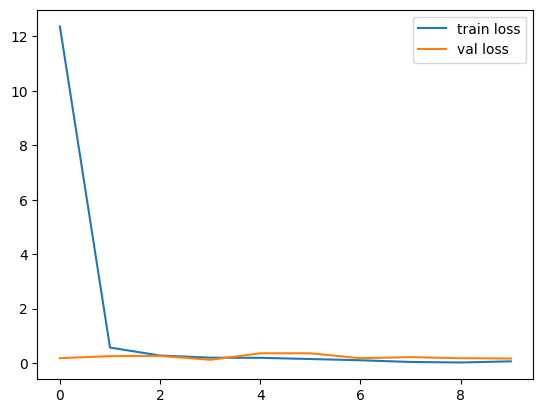

In [28]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()

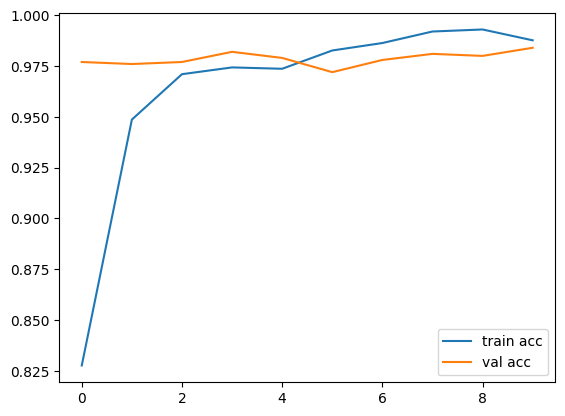

In [29]:
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

# Transfer learning without augmentation

In [31]:
batch_size = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size,
    shuffle = True,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size = IMAGE_SIZE,
    batch_size = batch_size
)

Found 3000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [32]:
def preprocess(image, label):
  return preprocess_input(image), label

train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess)

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [34]:
ptm = PretrainedModel(
    input_shape = IMAGE_SIZE + [3],
    weights = 'imagenet',
    include_top = False,
)


In [35]:
x = Flatten()(ptm.output)

In [36]:
model = Model(ptm.input, x)

In [37]:
xtrain = model.predict(train_ds)
xtest = model.predict(valid_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step


In [39]:
ytrain = np.concatenate([y for x, y in train_ds])
ytest = np.concatenate([y for x, y in valid_ds])

In [42]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scalar.fit(xtrain)
xtrain = scalar.transform(xtrain)
xtest = scalar.transform(xtest)

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(xtrain, ytrain)
print(rf.score(xtrain, ytrain))
print(rf.score(xtest, ytest))

1.0
0.982


In [44]:
i = Input(shape=(xtrain.shape[1],))
x = Dense(64, activation='relu')(i)
x = Dense(1, activation='sigmoid')(x)

linear_model = Model(i, x)

In [45]:
linear_model.compile(loss='binary_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

In [46]:
linear_model.fit(xtrain, ytrain, epochs=10, validation_data=(xtest, ytest))

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9553 - loss: 0.3475 - val_accuracy: 0.9750 - val_loss: 0.1157
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9937 - loss: 0.0220 - val_accuracy: 0.9740 - val_loss: 0.1823
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9993 - loss: 0.0045 - val_accuracy: 0.9740 - val_loss: 0.1759
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9730 - val_loss: 0.1760
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9710 - val_loss: 0.1763
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9720 - val_loss: 0.1766
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9720 - val_loss: 0.1770
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9720 - val_

In [47]:
r = linear_model.history

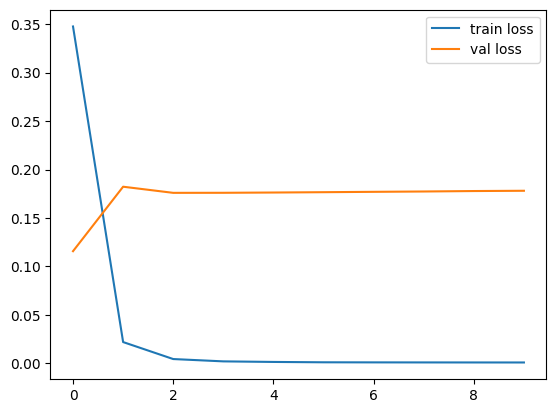

In [48]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()`

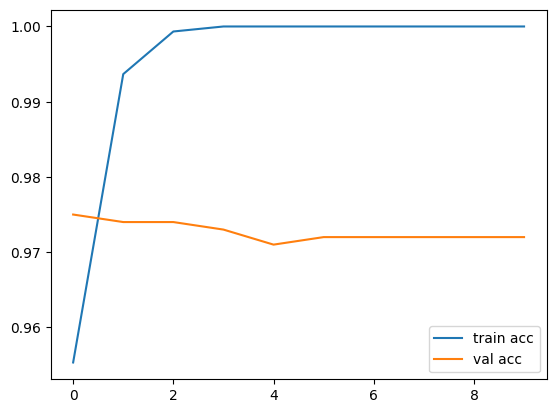

In [49]:
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()